In [1]:
##% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

from popy.io_tools import *
from popy.behavior_data_tools import *
from behav_analysis_tools import *
from popy.config import COLORS

# fontsize 12
plt.rcParams.update({'font.size': 8})


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-ee_waesh because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:

def plot_strategy_change(dates, reward_rates, selected_target):
    monkeys = dates.keys()

    # plot
    fig, axs = plt.subplots(2, len(monkeys), figsize=(4*len(monkeys), 4), sharex=True, gridspec_kw={'hspace': 0.1})

    for i, monkey in enumerate(monkeys):
        # plot data
        axs[1, i].plot(dates[monkey], reward_rates[monkey], 'o', color='k', markersize=4, alpha=.5)
        for target in [1, 2, 3]:
            axs[0, i].plot(dates[monkey], selected_target[monkey][target], marker='o', alpha=.5, label=f'target {target}', color=COLORS[f'target_{target}'], markersize=4)

        # plot settings
        ax = axs[1, i]
        ax.axhline(.25, color='gray', linestyle='--')
        ax.axhline(.7, color='gray', linestyle='--')
        ax.set_ylabel('Mean reward rate')
        ax.set_ylim(.20, .75)
        # set xtick density for every 3 months, formatted as 'YY-MM'
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xlabel('date (mm-yy)')

        ax = axs[0, i]
        ax.set_title('Monkey ' + monkey.upper() + ' (n sessions: ' + str(len(dates[monkey])) + ')')
        ax.axhline(1/3, color='gray', linestyle='--')
        ax.set_ylim(-0, .8)
        ax.set_ylabel('Target selection (%)')
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

    ax.legend(loc='upper center', bbox_to_anchor=(1.15, 1), ncol=1, frameon=False)

    return fig, axs


def get_reward_rate_and_selected_target(behav_all_original):
    behav_all = behav_all_original.copy()
    def conv_time(t):
        dd, mm, yy = t[:2], t[2:4], t[4:6]
        date_time = np.datetime64(f'20{yy}-{mm}-{dd}')
        return date_time
        
    monkeys = behav_all.monkey.unique()
    dates = {monkey: [] for monkey in monkeys}
    reward_rates = {monkey: [] for monkey in monkeys}
    proba_best_target = {monkey: [] for monkey in monkeys}
    selected_target = {monkey: {1: [], 2: [], 3: []} for monkey in monkeys}

    for monkey in monkeys:
        behav_all_monkey = behav_all.loc[behav_all.monkey == monkey]
        behav_all_monkey = behav_all_monkey.sort_values('date_of_recording')

        # get measurement dates
        dates_temp = behav_all_monkey.session.unique()
        dates[monkey] = [conv_time(t) for t in dates_temp]

        # get average reward rate and selected target
        for i, session in enumerate(behav_all_monkey.session.unique()):
            session_data = behav_all_monkey.loc[behav_all_monkey.session == session]
            
            # get average reward rate
            reward_rates[monkey].append(np.mean(session_data.feedback.values))
            proba_best_target[monkey].append(np.mean(session_data.if_best_target.values))

            # get percent of target selection
            for target in [1, 2, 3]:
                avg_selection = np.mean(session_data.target == target)
                selected_target[monkey][target].append(np.mean(session_data.target == target))

    return dates, reward_rates, selected_target, proba_best_target


In [3]:
# load all session data, remove those labeled as invalid
behav = load_behavior()

#behav = drop_time_fields(behav)
behav = add_switch_info(behav)
behav = add_trial_in_block(behav)
behav = add_date_of_recordig(behav)
behav = drop_time_fields(behav)
behav['if_best_target'] = behav['target'] == behav['best_target']

behav = behav.dropna()
behav

,date_of_recording,monkey,session,trial_id,block_id,best_target,target,feedback,switch,trial_id_in_block,if_best_target
1,2020-07-01,ka,010720,1,0,2,3.0,0.0,0.0,1,False
2,2020-07-01,ka,010720,2,0,2,1.0,1.0,1.0,2,False
3,2020-07-01,ka,010720,3,0,2,1.0,0.0,0.0,3,False
4,2020-07-01,ka,010720,4,0,2,3.0,1.0,1.0,4,False
5,2020-07-01,ka,010720,5,0,2,3.0,0.0,0.0,5,False
...,...,...,...,...,...,...,...,...,...,...,...
39214,2022-08-31,po,310822,419,9,2,1.0,0.0,0.0,35,False
39215,2022-08-31,po,310822,420,9,2,1.0,1.0,0.0,36,False
39216,2022-08-31,po,310822,421,9,2,1.0,1.0,0.0,37,False
39217,2022-08-31,po,310822,422,9,2,1.0,1.0,0.0,38,False


Number of switch trials per session:
	Monkey KA: 38.42 ± 14.23 switches per session
	Monkey PO: 61.51 ± 30.91 switches per session


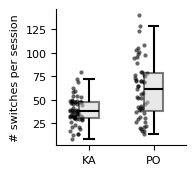

In [4]:
# create boxplot with scatter points for number of switches per session
fig, ax = plt.subplots(1, 1, figsize=(2, 1.8))

# prepare data for seaborn
data_list = []
for monkey in behav.monkey.unique():
    behav_monkey = behav.loc[behav.monkey == monkey]
    n_switches_per_session = behav_monkey.groupby('session')['switch'].sum()
    for value in n_switches_per_session.values:
        data_list.append({'Monkey': monkey.upper(), 'Switches': value})

df_switches = pd.DataFrame(data_list)

# create boxplot with seaborn
sns.boxplot(data=df_switches, x='Monkey', y='Switches', 
            color='lightgray', width=0.3, ax=ax,
            boxprops=dict(alpha=0.5, edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=1.5),
            showfliers=False)

# add scatter points slightly to the left of the box
strip = sns.stripplot(data=df_switches, x='Monkey', y='Switches', 
                      color='black', alpha=0.6, size=3, ax=ax,
                      jitter=0.1, zorder=0)

# shift stripplot points to the left
for collection in strip.collections:
    offsets = collection.get_offsets()
    offsets[:, 0] = offsets[:, 0] - 0.2  # shift left
    collection.set_offsets(offsets)

# formatting
ax.set_ylabel('# switches per session')
ax.set_xlabel('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

# print statistics
print('Number of switch trials per session:')
for monkey in df_switches['Monkey'].unique():
    monkey_data = df_switches[df_switches['Monkey'] == monkey]['Switches'].values
    print(f'\tMonkey {monkey}: {monkey_data.mean():.2f} ± {monkey_data.std():.2f} switches per session')

# save as png, 300 dpi
plt.savefig('figs/number_of_switches_per_session.svg', dpi=300)

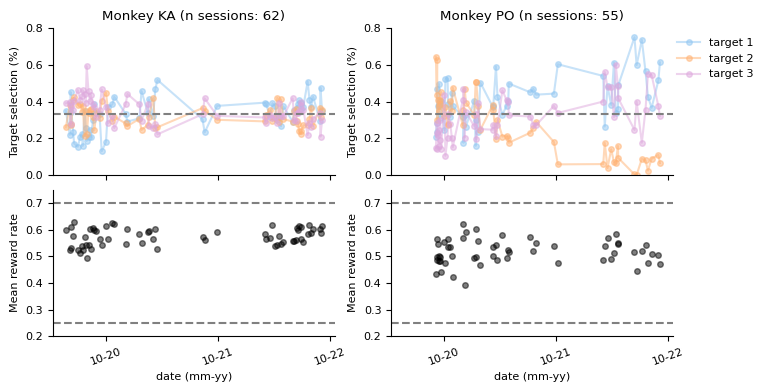

In [5]:
# get reward rates and selected target statistics over sessions
behav_monkey = add_date_of_recordig(behav)
dates, reward_rates, selected_target, proba_best_target = get_reward_rate_and_selected_target(behav_monkey)

# plot strategy change
fig, axs = plot_strategy_change(dates, reward_rates, selected_target)

# save as png, 300 dpi
fig.savefig('figs/changing_strategy.png', dpi=300, bbox_inches='tight')

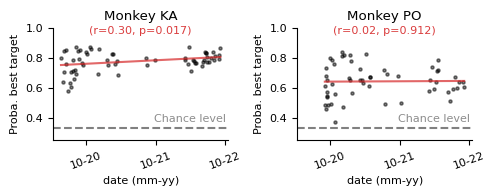

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(5, 2), sharex=True)
for m, monkey in enumerate(dates.keys()):
    ax = axs[m]
    dates_, rates_ = dates[monkey], proba_best_target[monkey]
    ax.scatter(dates_, rates_, color='k', alpha=.5, s=5)

    # fit linear regression line, show line and add stats in title
    x = np.array([date.astype('datetime64[D]').astype(int) for date in dates_])
    y = np.array(rates_)
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_fit = np.array([min(x), max(x)])
    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, color='tab:red', alpha=0.7)
    
    ax.set_title(f'Monkey {monkey.upper()}')
    ax.text(0.5, .93, f'(r={r_value:.2f}, p={p_value:.3f})', 
            transform=ax.transAxes, ha='center', va='bottom', color='tab:red', fontsize=8, alpha=0.9)
    ax.set_xlabel('date (mm-yy)')
    ax.set_ylabel('Proba. best target')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.axhline(.33, linestyle='dashed', color='grey')
    # print chance level on the gery one
    ax.text(0.78, .15, 'Chance level', transform=ax.transAxes, ha='center', va='bottom', color='grey', fontsize=8, alpha=0.9)

    ax.set_ylim(.25, 1)

plt.tight_layout()
# save as png, 300 dpi
plt.savefig('figs/changing_strategy_reward_rate_over_time.svg', dpi=300, bbox_inches='tight')
